# *Required Libraries*

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load CSV into a Pandas DataFrame
class_labels = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "Unknown"]


def print_result(csv_file, title):
    df = pd.read_csv(csv_file, header=None).fillna(0)
    conf_matrix = df.values
    num_classes = conf_matrix.shape[0]

    # Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt="d", cmap="Blues", linewidths=0.5, xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(title)
    plt.show()

    # Metrics
    correct_predictions = np.trace(conf_matrix)
    total_predictions = np.sum(conf_matrix)
    accuracy = correct_predictions / total_predictions
    precision = []
    recall = []
    f1_score = []

    for i in range(num_classes):
        TP = conf_matrix[i, i]
        FP = np.sum(conf_matrix[:, i]) - TP
        FN = np.sum(conf_matrix[i, :]) - TP

        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        rec = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        precision.append(prec)
        recall.append(rec)
        f1_score.append(f1)

    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1_score)

    # Print results
    print(f"Accuracy: {float(accuracy):.6f}")
    print(f"Precision (per class): {[float(round(p, 6)) for p in precision]}")
    print(f"Recall (per class): {[float(round(r, 6)) for r in recall]}")
    print(f"F1-score (per class): {[float(round(f, 6)) for f in f1_score]}")
    print(f"Macro-Averaged Precision: {float(macro_precision):.6f}")
    print(f"Macro-Averaged Recall: {float(macro_recall):.6f}")
    print(f"Macro-Averaged F1-score: {float(macro_f1):.6f}")


# **Standard and Enhanced**

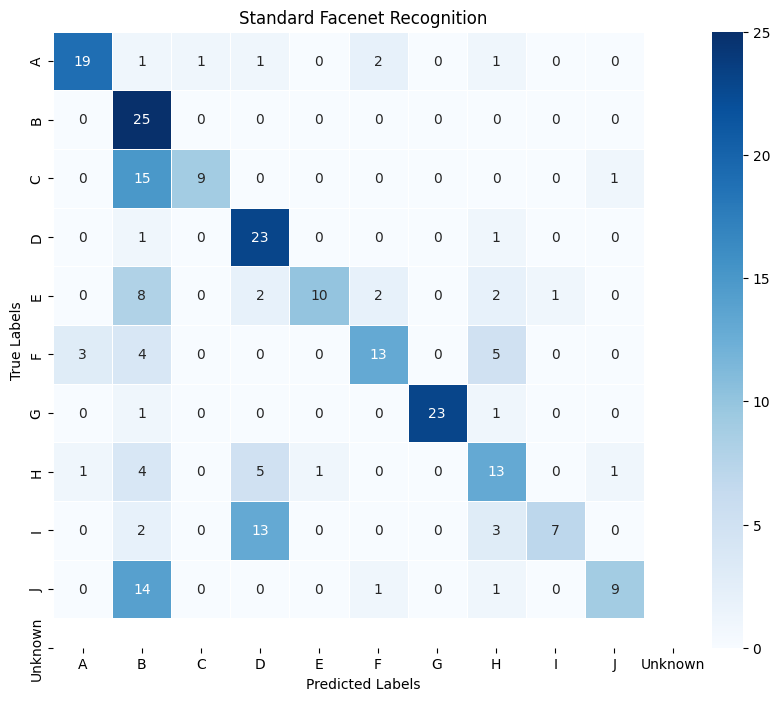

Accuracy: 0.604000
Precision (per class): [0.826087, 0.333333, 0.9, 0.522727, 0.909091, 0.722222, 1.0, 0.481481, 0.875, 0.818182]
Recall (per class): [0.76, 1.0, 0.36, 0.92, 0.4, 0.52, 0.92, 0.52, 0.28, 0.36]
F1-score (per class): [0.791667, 0.5, 0.514286, 0.666667, 0.555556, 0.604651, 0.958333, 0.5, 0.424242, 0.5]
Macro-Averaged Precision: 0.738812
Macro-Averaged Recall: 0.604000
Macro-Averaged F1-score: 0.601540


In [5]:
print_result("svm_standard.csv", "Standard Facenet Recognition")

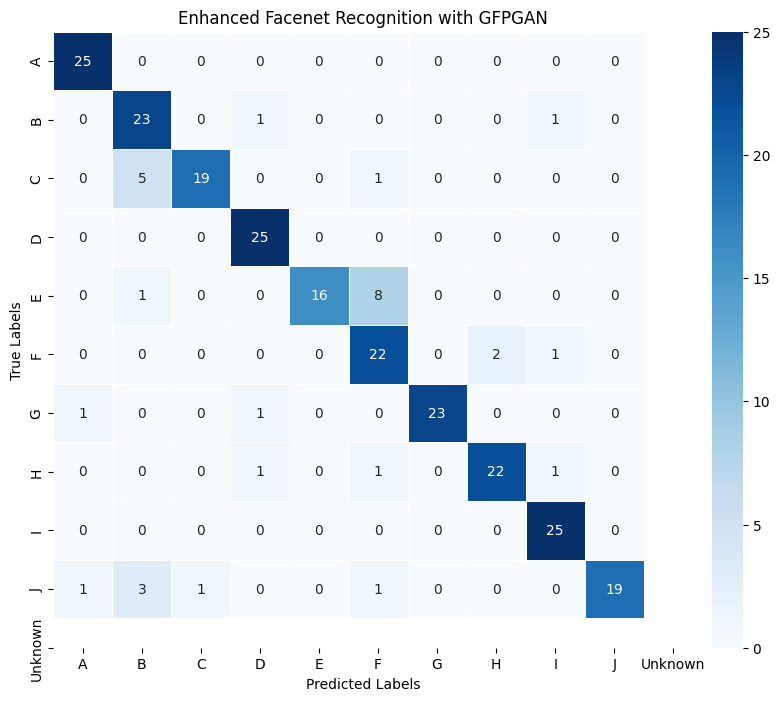

Accuracy: 0.876000
Precision (per class): [0.925926, 0.71875, 0.95, 0.892857, 1.0, 0.666667, 1.0, 0.916667, 0.892857, 1.0]
Recall (per class): [1.0, 0.92, 0.76, 1.0, 0.64, 0.88, 0.92, 0.88, 1.0, 0.76]
F1-score (per class): [0.961538, 0.807018, 0.844444, 0.943396, 0.780488, 0.758621, 0.958333, 0.897959, 0.943396, 0.863636]
Macro-Averaged Precision: 0.896372
Macro-Averaged Recall: 0.876000
Macro-Averaged F1-score: 0.875883


In [4]:
print_result("svm_enhanced.csv", "Enhanced Facenet Recognition with GFPGAN")